In [ ]:
pip install tensorflow

# **Section 1: Preprocessing**

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# 1. Dataset load karein (Apni file ka sahi path check kar lein)
df = pd.read_excel('combined_urls.xlsx')

# Shuffle data taake safe aur phishing mix ho jayein
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total Rows: {df.shape[0]}")
print(df.head())

Total Rows: 16420
                               url  label
0         https://jamulcasinow.com      1
1      https://www.manhwaread.com/      0
2  https://tzy---start.webflow.io/      1
3          https://www.wetest.net/      0
4      coronarhapsodyrhyoutube.com      1


In [ ]:
# URLs ki length nikallein
df['url_length'] = df['url'].astype(str).str.len()

# Percentiles check karein
print("--- URL Length Distribution ---")
print(df['url_length'].quantile([0.75, 0.90, 0.95, 0.99]))
print(f"Maximum URL length: {df['url_length'].max()}")

--- URL Length Distribution ---
0.75    30.0
0.90    42.0
0.95    55.0
0.99    86.0
Name: url_length, dtype: float64
Maximum URL length: 393


In [ ]:
MAX_LEN = 150

# 1. Character-level Tokenizer setup
tokenizer = Tokenizer(char_level=True, lower=True, oov_token='<OOV>')
tokenizer.fit_on_texts(df['url'].astype(str))
vocab_size = len(tokenizer.word_index) + 1

# Text ko integer sequences mein badlein
sequences = tokenizer.texts_to_sequences(df['url'].astype(str))

# 2. Train-Test Split (Sabse PEHLE data alag karein!)
X = sequences
y = df['label'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Post-Padding (Split ke BAAD padding apply karein)
X_train = pad_sequences(X_train_raw, maxlen=MAX_LEN, padding='post')
X_test = pad_sequences(X_test_raw, maxlen=MAX_LEN, padding='post')

print("--- Data Preprocessing Completed ---")
print(f"Vocabulary Size (Unique Characters): {vocab_size}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

--- Data Preprocessing Completed ---
Vocabulary Size (Unique Characters): 86
X_train shape: (13136, 150)
X_test shape: (3284, 150)


In [ ]:
import json

# Tokenizer configuration ko naye siray se JSON mein badlein
tokenizer_json = tokenizer.to_json()

with open('tokenizer_config_bilstm.json', 'w', encoding='utf-8') as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))

print("Updated Tokenizer configuration saved to 'tokenizer_config_bilstm.json'!")

Updated Tokenizer configuration saved to 'tokenizer_config_bilstm.json'!


# **Section 2: Architecture**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout

# BiLSTM Model - Clean List Style Initialization
model = Sequential([
    Input(shape=(150,)),                               # Input size jo Section 1 mein set kiya (150)
    Embedding(input_dim=vocab_size, output_dim=64),    # Dynamic vocab_size jo unique characters + OOV hai
    Bidirectional(LSTM(64)),                           # Core BiLSTM layer (Dono taraf se parhne wala engine)
    Dropout(0.3),                                      # Overfitting se bachane ke liye pehla jhatka
    Dense(units=64, activation='relu'),                # Complex features ko filter karne ke liye intermediate layer
    Dropout(0.3),                                      # Doosra dropout safety filter
    Dense(units=1, activation='sigmoid')               # Final Output Layer (Safe vs Phishing)
])

# Structure print karein
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 64)        │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,873 (312.00 KB)

 Trainable params: 79,873 (312.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Model compilation
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 2. Callbacks (Ab yeh X_train se nikle validation loss ko monitor karenge)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# 3. Training Start (With Automatic Validation Split)
print("--- Training BiLSTM Model with Isolated Validation Set ---")
history = model.fit(
    X_train, y_train,
    validation_split=0.1,  # Keras khud X_train se 10% data nikal kar validation karega
    epochs=20,
    batch_size=64,
    callbacks=callbacks
)

--- Training BiLSTM Model with Isolated Validation Set ---
Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 28s 136ms/step - accuracy: 0.9898 - loss: 0.0403 - val_accuracy: 0.9878 - val_loss: 0.0492 - learning_rate: 0.0010
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 41s 137ms/step - accuracy: 0.9914 - loss: 0.0325 - val_accuracy: 0.9878 - val_loss: 0.0464 - learning_rate: 0.0010
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 26s 139ms/step - accuracy: 0.9931 - loss: 0.0257 - val_accuracy: 0.9878 - val_loss: 0.0340 - learning_rate: 0.0010
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 41s 137ms/step - accuracy: 0.9971 - loss: 0.0118 - val_accuracy: 0.9954 - val_loss: 0.0232 - learning_rate: 0.0010
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 25s 137ms/step - accuracy: 0.9984 - loss: 0.0070 - val_accuracy: 0.9947 - val_loss: 0.0294 - learning_rate: 0.0010
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9986 - loss: 0.0075
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
18

In [8]:
print("--- 🚨 FINAL BOARD EXAM ON UNSEEN TEST DATA 🚨 ---")

# Model ko unseen X_test aur y_test par evaluate karein
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"\nTest Data Loss: {test_loss:.6f}")
print(f"Test Data Accuracy: {test_accuracy * 100:.2f}%")

--- 🚨 FINAL BOARD EXAM ON UNSEEN TEST DATA 🚨 ---
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9994 - loss: 0.0055

Test Data Loss: 0.005547
Test Data Accuracy: 99.94%


In [9]:
# Model ko Colab ki temporary hard drive par `.keras` format mein save karein
model.save('phishing_bilstm_model.keras')

print("🚀 BiLSTM Model successfully saved as 'phishing_bilstm_model.keras'!")

🚀 BiLSTM Model successfully saved as 'phishing_bilstm_model.keras'!


# **Visualize**

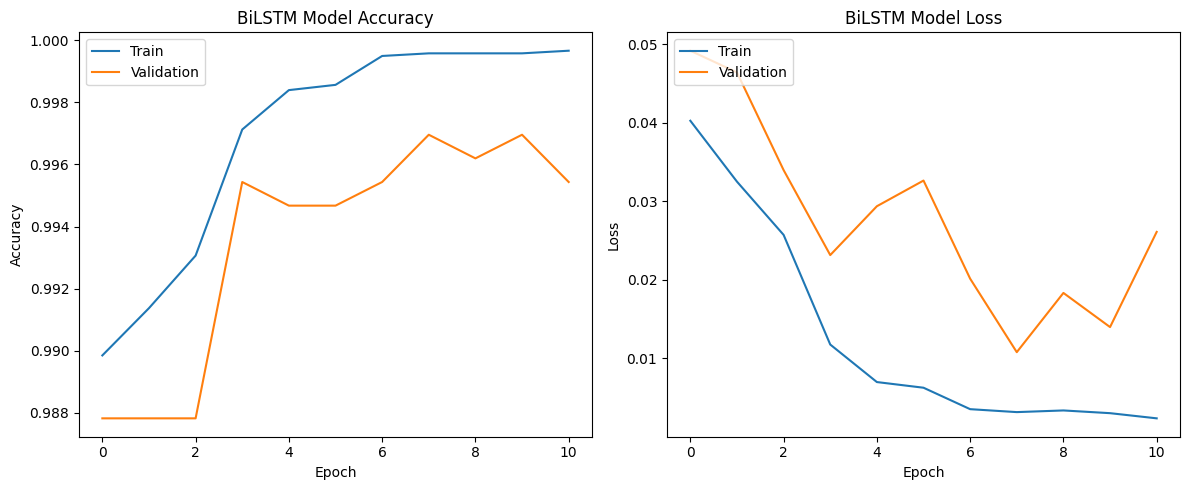

In [10]:
import matplotlib.pyplot as plt

# 1. Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('BiLSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# 2. Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('BiLSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step
### BiLSTM Detailed Classification Report ###

              precision    recall  f1-score   support

       Clean       1.00      1.00      1.00      2000
    Phishing       1.00      1.00      1.00      1284

    accuracy                           1.00      3284
   macro avg       1.00      1.00      1.00      3284
weighted avg       1.00      1.00      1.00      3284



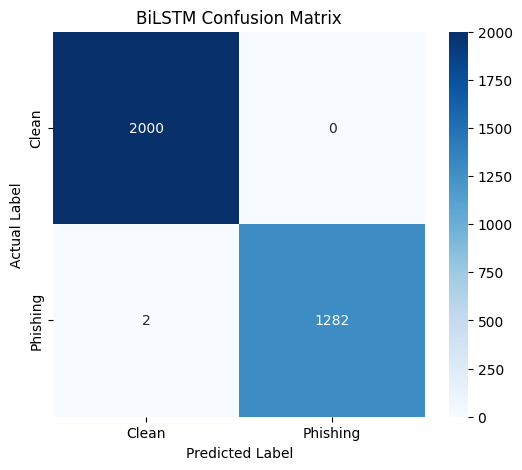

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# 1. Unseen test set par probabilities nikalen
y_pred_proba = model.predict(X_test)
# 0.5 ke threshold se binary classification labels (0 ya 1) banayein
y_pred = (y_pred_proba > 0.5).astype(int)

# 2. Detailed Classification Report Print Karein
print("### BiLSTM Detailed Classification Report ###\n")
print(classification_report(y_test, y_pred, target_names=['Clean', 'Phishing']))

# 3. Confusion Matrix Plot Karein
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Clean', 'Phishing'], yticklabels=['Clean', 'Phishing'])
plt.title('BiLSTM Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## **Testing the model to see if it holds up to the real world**

In [12]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── 1. Load saved BiLSTM model ───────────────────────────────────────────────
model = load_model('phishing_bilstm_model.keras')

# ── 2. Rebuild tokenizer from your combined dataset ──────────────────────────
# Must match exactly what was used during training
tokenizer = Tokenizer(char_level=True, oov_token='<OOV>')
tokenizer.fit_on_texts(df['url'].astype(str))   # Apni BiLSTM notebook ka dataframe 'df' use kar rahe hain
MAX_LEN = 150                                   # BiLSTM ka trained sequence length

# ── 3. Test URLs ─────────────────────────────────────────────────────────────
test_cases = [
    # (url, expected_label, description)

    # --- Legitimate ---
    ("https://www.hec.gov.pk/",                                    0, "HEC Pakistan"),
    ("https://www.python.org/downloads/release/python-3120/",      0, "Python downloads"),
    ("https://huggingface.co/models",                              0, "HuggingFace"),
    ("https://stackoverflow.com/questions/tagged/tensorflow",      0, "Stack Overflow"),
    ("https://www.dawn.com/news/1900000",                          0, "Dawn News"),
    ("https://portal.azure.com/#home",                             0, "Azure portal"),
    ("https://colab.research.google.com/drive/1abc123",            0, "Google Colab"),
    ("https://www.kaggle.com/competitions",                        0, "Kaggle"),

    # --- Typosquatting ---
    ("http://paypa1.com/signin/verify?token=abc123",               1, "paypal typo (1→l)"),
    ("http://g00gle-security.com/account/confirm",                 1, "google typo (oo→00)"),
    ("http://arnazon-prime.com/billing/update",                    1, "amazon typo"),
    ("http://faceb00k-login.tk/recover/password",                  1, "facebook typo + .tk"),

    # --- IP-based ---
    ("http://192.168.1.1/admin/login.php",                         1, "private IP"),
    ("http://45.33.32.156/secure/banking/update",                  1, "raw public IP"),

    # --- Brand-in-subdomain + junk TLD ---
    ("http://netflix.com.account-verify.xyz/login",                1, "netflix brand in subdomain"),
    ("http://paypal.com.secure-update.ru/verify",                  1, "paypal brand in subdomain"),
    ("http://apple.com-id-locked.gq/recover",                      1, "apple brand in domain"),

    # --- Edge cases ---
    ("http://bit.ly/3xKq9mP",                                      None, "URL shortener (ambiguous)"),
    ("https://docs.google.com/forms/d/e/1FAIpQLSd8x9f/viewform",  None, "Google Forms (legit but phishing-used)"),
]

# ── 4. Preprocess & predict ───────────────────────────────────────────────────
urls       = [tc[0] for tc in test_cases]
sequences  = tokenizer.texts_to_sequences(urls)
X_test_rw  = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

proba = model.predict(X_test_rw, verbose=0).flatten()
preds = (proba > 0.5).astype(int)

# ── 5. Print results ──────────────────────────────────────────────────────────
print(f"\n{'URL':<55} {'Conf':>6}  {'Pred':>8}  {'Expected':>8}  {'Result':>6}")
print("─" * 95)

correct = 0
total_labeled = 0

for (url, expected, desc), prob, pred in zip(test_cases, proba, preds):
    label     = "PHISHING" if pred == 1 else "SAFE"
    conf_str  = f"{prob:.3f}"

    if expected is None:
        result_str = "—  edge"
    else:
        total_labeled += 1
        if pred == expected:
            correct += 1
            result_str = "✓"
        else:
            result_str = "✗  ← WRONG"

    exp_str = "phishing" if expected == 1 else ("safe" if expected == 0 else "?")
    print(f"{url:<55} {conf_str:>6}  {label:>8}  {exp_str:>8}  {result_str}")

print("─" * 95)
print(f"\nLabeled test accuracy: {correct}/{total_labeled} ({100*correct/total_labeled:.1f}%)")
print(f"(Edge cases excluded from score — observe their confidence manually)\n")


URL                                                       Conf      Pred  Expected  Result
───────────────────────────────────────────────────────────────────────────────────────────────
https://www.hec.gov.pk/                                  0.001      SAFE      safe  ✓
https://www.python.org/downloads/release/python-3120/    1.000  PHISHING      safe  ✗  ← WRONG
https://huggingface.co/models                            1.000  PHISHING      safe  ✗  ← WRONG
https://stackoverflow.com/questions/tagged/tensorflow    1.000  PHISHING      safe  ✗  ← WRONG
https://www.dawn.com/news/1900000                        1.000  PHISHING      safe  ✗  ← WRONG
https://portal.azure.com/#home                           1.000  PHISHING      safe  ✗  ← WRONG
https://colab.research.google.com/drive/1abc123          1.000  PHISHING      safe  ✗  ← WRONG
https://www.kaggle.com/competitions                      1.000  PHISHING      safe  ✗  ← WRONG
http://paypa1.com/signin/verify?token=abc123             1.00